# 中文场景文字识别Baseline——基于PaddleOCR

## 常规赛简介
飞桨(PaddlePaddle)以百度多年的深度学习技术研究和业务应用为基础，集深度学习核心框架、基础模型库、端到端开发套件、工具组件和服务平台于一体，是中国首个开源开放、技术领先、功能完备的产业级深度学习平台。更多飞桨资讯，点击[此处](https://www.paddlepaddle.org.cn/)查看。

飞桨常规赛由百度飞桨于2019年发起，面向全球AI开发者，赛题范围广，涵盖领域多。常规赛旨在通过长期发布的经典比赛项目，为开发者提供学习锻炼机会，助力大家在飞将大赛中获得骄人成绩。

参赛选手需使用飞桨框架，基于特定赛题下的真实行业数据完成并提交任务。常规赛采取月度评比方式，为打破历史最高记录选手和当月有资格参与月度评奖的前10名选手提供飞桨特别礼包奖励。更多惊喜，更多收获，尽在飞桨常规赛。

## 数据集描述
本次赛题数据集共包括6万张图片，其中5万张图片作为训练集，1万张作为测试集。数据集采自中国街景，并由街景图片中的文字行区域（例如店铺标牌、地标等等）截取出来而形成。数据集中所有图像都经过预处理，高度统一为48像素，如下图所示：

![](https://ai-studio-static-online.cdn.bcebos.com/557b2c744ec74d25b3183e8d5ca239396548cdb3312c4fdcaf85d5d259cf4e9c)

标注：g3738

为了避免标注上的歧义，竞赛组委会在计算指标之前对文字行进行如下预处理：
- 全角统一为半角
- 英文字符统一为小写
- 中文字符统一为简体
- 忽略所有空格和符号

# 快速开始
PaddleOCR旨在打造一套丰富、领先、且实用的OCR工具库，助力使用者训练出更好的模型，并应用落地。该基线使用PaddleOCR的推理模型，助力开发者快速完成结果文件的生成。

悄咪咪告诉你：用 **hub.fastgit.org** 代替 **github.com** 会有意想不到的效果哦~~
```
! git clone https://hub.fastgit.org/PaddlePaddle/PaddleOCR
! pip install -r PaddleOCR/requirements.txt
```
考虑到提交结果文件的需要，我将 `PaddleOCR/tools/infer/predict_rec.py` 进行了修改，包括返回结果的后处理（全角转半角、英文大写转小写、删除符合和空格）以及结果文件的上交格式，如果重新clone仓库需要再一次修改，比较麻烦。

In [1]:
!git clone https://gitee.com/paddlepaddle/PaddleOCR
! pip install -r PaddleOCR/requirements.txt

fatal: destination path 'PaddleOCR' already exists and is not an empty directory.


Ignoring lmdb: markers 'python_version < "3.9"' don't match your environment


## 模型下载
[PP-OCR 1.1系列模型列表（9月17日更新）](https://github.com/PaddlePaddle/PaddleOCR/blob/develop/README_ch.md#pp-ocr-11%E7%B3%BB%E5%88%97%E6%A8%A1%E5%9E%8B%E5%88%97%E8%A1%A89%E6%9C%8817%E6%97%A5%E6%9B%B4%E6%96%B0)
![](https://ai-studio-static-online.cdn.bcebos.com/55b66105f8a6464a9a4cf4e987983c3cc5fca21e1c2b4639aa6c68f8d7a135ec)

In [2]:
! pip install paddlepaddle -i https://pypi.tuna.tsinghua.edu.cn/simple

Looking in indexes: https://pypi.tuna.tsinghua.edu.cn/simple


In [3]:
!tar -xf model/ch_PP-OCRv4_det_infer.tar  -C model/
!tar -xf model/ch_PP-OCRv4_det_train.tar  -C model/

In [4]:
# ! wget -P model/server/infer https://paddleocr.bj.bcebos.com/20-09-22/server/rec/ch_ppocr_server_v1.1_rec_infer.tar && \
#   cd model/server/infer && \
#   tar xf ch_ppocr_server_v1.1_rec_infer.tar && \
#   rm ch_ppocr_server_v1.1_rec_infer.tar

## 解压数据
AI Studio的机制会在每次启动项目的时候把 data 目录下的文件初始化。为了优化启动速度，我们可以将内存占用大的数据解压到 data 目录下，内存占用小的文件放到 work 目录下，这样每次启动时只需花费解压一次数据的时间，更快完成项目加载。

In [5]:
! cd data && \
  unzip -qo data62842/train_images.zip && \
  unzip -qo data62843/test_images.zip && \
  cp data62842/train_label.csv . && \
  rm -r __MACOSX

'unzip' �����ڲ����ⲿ���Ҳ���ǿ����еĳ���
���������ļ���


## 模型预测

In [6]:
# ! cd PaddleOCR && \
#   python tools/infer/predict_rec.py \
#   --image_dir="../data/test_images" \
#   --rec_model_dir="../model/server/infer/ch_ppocr_server_v1.1_rec_infer"

# 继续冲刺
赛程赛制中有写道：**每月1-5日公布上一个月总榜。高于评奖分数（85分）且排名前10名选手可获得飞桨周边特别礼包（飞桨周边+100小时算力卡）。** 我们使用中英文通用OCR模型，可以得到82左右的分数，这显然不满足评奖条件，继续改进模型是有必要的。

在上面的模型预测中，我们使用的是PaddleOCR提供的推理模型，520W左右的数据集（真实数据26W+合成数据500W）训练，能够较为笼统地概括中文场景的文字特点。然而，为了针对常规赛的要求，我们可以在原模型的基础上用训练集微调，进一步提升我们模型的准确率~

在PaddleOCR预训练模型的基础上做微调，大体需要下面几步：
1. 准备训练数据
	- 图片
   - 标签
   - 词典
2. 修改配置文件
	- 训练配置
   - 数据读取
3. 下载模型
***
**注意：**
- 训练过程中保存的checkpoints模型（预训练模型）结构为 `*.pdmodel` `*.pdopt` `*.pdparams`
- inference模型结构为 `model` `params`

更多介绍：[PaddleOCR整体目录结构](https://github.com/PaddlePaddle/PaddleOCR/blob/develop/doc/doc_ch/tree.md#%E6%95%B4%E4%BD%93%E7%9B%AE%E5%BD%95%E7%BB%93%E6%9E%84)

## 数据准备
图像数据已经解压过，就不重复了，这里我们主要谈谈标签的预处理。上面说过，为了避免标注上的歧义，竞赛组委会在计算指标之前对文字行进行过如下预处理：
- 全角统一为半角
- 英文字符统一为小写
- 中文字符统一为简体
- 忽略所有空格和符号
***
`train_label.csv` 文件格式如下：
| name | value |
| :-: | :-: | 
| 0.jpg     | 拉拉     | 
| 1.jpg | ６号 |
| 2.jpg | 胖胖 |
| ... | ... |
| 49999.jpg | 脑维修 |


我们使用Pandas读取 train_label.csv 文件，对每一行的标注信息进行处理，并且删除处理后为空字符的标注，将其保存为 .txt 文件。

In [7]:
import pandas as pd

def Q2B(s):
    """全角转半角"""
    inside_code=ord(s)
    if inside_code==0x3000:
        inside_code=0x0020
    else:
        inside_code-=0xfee0
    if inside_code<0x0020 or inside_code>0x7e: #转完之后不是半角字符返回原来的字符
        return s
    return chr(inside_code)

def stringQ2B(s):
    """把字符串全角转半角"""
    return "".join([Q2B(c) for c in s])

def is_chinese(s):
    """判断unicode是否是汉字"""
    for c in s:
        if c < u'\u4e00' or c > u'\u9fa5':
            return False
    return True

def is_number(s):
    """判断unicode是否是数字"""
    for c in s:
        if c < u'\u0030' or c > u'\u0039':
            return False
    return True

def is_alphabet(s):
    """判断unicode是否是英文字母"""
    for c in s:
        if c < u'\u0061' or c > u'\u007a':
            return False
    return True

def del_other(s):
    """判断是否非汉字，数字和小写英文"""
    res = str()
    for c in s:
        if not (is_chinese(c) or is_number(c) or is_alphabet(c)):
            c = ""
        res += c
    return res


df = pd.read_csv("data/train_label.csv", encoding="gbk")
name, value = list(df.name), list(df.value)
for i, label in enumerate(value):
    # 全角转半角
    label = stringQ2B(label)
    # 大写转小写
    label = "".join([c.lower() for c in label])
    # 删除所有空格符号
    label = del_other(label)
    value[i] = label

# 删除标签为""的行
data = zip(name, value)
data = list(filter(lambda c: c[1]!="", list(data)))
# 保存到work目录
with open("data/train_label.txt", "w") as f:
    for line in data:
        f.write(line[0] + "\t" + line[1] + "\n")


A module that was compiled using NumPy 1.x cannot be run in
NumPy 2.2.6 as it may crash. To support both 1.x and 2.x
versions of NumPy, modules must be compiled with NumPy 2.0.
Some module may need to rebuild instead e.g. with 'pybind11>=2.12'.

If you are a user of the module, the easiest solution will be to
downgrade to 'numpy<2' or try to upgrade the affected module.
We expect that some modules will need time to support NumPy 2.

Traceback (most recent call last):  File "<frozen runpy>", line 198, in _run_module_as_main
  File "<frozen runpy>", line 88, in _run_code
  File "d:\Anaconda\envs\mynev\Lib\site-packages\ipykernel_launcher.py", line 18, in <module>
    app.launch_new_instance()
  File "d:\Anaconda\envs\mynev\Lib\site-packages\traitlets\config\application.py", line 1075, in launch_instance
    app.start()
  File "d:\Anaconda\envs\mynev\Lib\site-packages\ipykernel\kernelapp.py", line 739, in start
    self.io_loop.start()
  File "d:\Anaconda\envs\mynev\Lib\site-packages\tor

ImportError: 
A module that was compiled using NumPy 1.x cannot be run in
NumPy 2.2.6 as it may crash. To support both 1.x and 2.x
versions of NumPy, modules must be compiled with NumPy 2.0.
Some module may need to rebuild instead e.g. with 'pybind11>=2.12'.

If you are a user of the module, the easiest solution will be to
downgrade to 'numpy<2' or try to upgrade the affected module.
We expect that some modules will need time to support NumPy 2.




A module that was compiled using NumPy 1.x cannot be run in
NumPy 2.2.6 as it may crash. To support both 1.x and 2.x
versions of NumPy, modules must be compiled with NumPy 2.0.
Some module may need to rebuild instead e.g. with 'pybind11>=2.12'.

If you are a user of the module, the easiest solution will be to
downgrade to 'numpy<2' or try to upgrade the affected module.
We expect that some modules will need time to support NumPy 2.

Traceback (most recent call last):  File "<frozen runpy>", line 198, in _run_module_as_main
  File "<frozen runpy>", line 88, in _run_code
  File "d:\Anaconda\envs\mynev\Lib\site-packages\ipykernel_launcher.py", line 18, in <module>
    app.launch_new_instance()
  File "d:\Anaconda\envs\mynev\Lib\site-packages\traitlets\config\application.py", line 1075, in launch_instance
    app.start()
  File "d:\Anaconda\envs\mynev\Lib\site-packages\ipykernel\kernelapp.py", line 739, in start
    self.io_loop.start()
  File "d:\Anaconda\envs\mynev\Lib\site-packages\tor

ImportError: 
A module that was compiled using NumPy 1.x cannot be run in
NumPy 2.2.6 as it may crash. To support both 1.x and 2.x
versions of NumPy, modules must be compiled with NumPy 2.0.
Some module may need to rebuild instead e.g. with 'pybind11>=2.12'.

If you are a user of the module, the easiest solution will be to
downgrade to 'numpy<2' or try to upgrade the affected module.
We expect that some modules will need time to support NumPy 2.



字典在 `ppocr/utils/ppocr_keys_v1.txt` 中有提供，是一个包含6623个字符的中文字典。字典有什么用呢？通过字典，可以在训练的时候把字符映射成字符的索引。这里针对训练集，写了一个3096个字符的字典，开发者可以按需选择。

In [8]:
def create_label_list(train_list):
    classSet = set()
    with open(train_list) as f:
        next(f)
        for line in f:
            img_name, label = line.strip().split("\t")
            for e in label:
                classSet.add(e)
    # 在类的基础上加一个blank
    classList = sorted(list(classSet))
    with open("data/label_list.txt", "w") as f:
        for c in classList:
            f.write("{}\n".format(c))

create_label_list("data/train_label.txt")

# 数据增强

In [60]:
# preprocess.py
import cv2
import numpy as np
# ========== 标准 OCR 预处理 ==========
def preprocess(img, target_h=48, target_w=256):
    """
    标准 OCR 预处理：
    1. 保持宽高比 resize 到目标高度
    2. 填充或裁剪到固定宽度
    3. 归一化到 [-1, 1]
    4. HWC -> CHW
    """
    h, w = img.shape[:2]
    ratio = target_h / float(h)
    new_w = int(w * ratio)

    # 按高度等比缩放
    img = cv2.resize(img, (new_w, target_h), interpolation=cv2.INTER_LINEAR)

    # 宽度不足填充黑边，过长则裁剪
    if new_w < target_w:
        pad = np.zeros((target_h, target_w, 3), dtype=np.uint8)
        pad[:, :new_w] = img
        img = pad
    else:
        img = img[:, :target_w]

    # 归一化
    img = img.astype('float32') / 255.0
    img = (img - 0.5) / 0.5

    # HWC -> CHW
    img = img.transpose((2, 0, 1))
    return paddle.to_tensor(img)

In [61]:
import paddle
import paddle.nn as nn
import sys
sys.path.append('./PaddleOCR')   # 告诉 Python 去这里找 ppocr
# sys.path.insert(0, '/home/aistudio/PaddleOCR')   # 确保路径正确
import os
import cv2
import numpy as np
from paddle.io import Dataset
from paddle.vision import transforms as T
#from preprocess import preprocess

from ppocr.data.imaug import RecAug, RandAugment

# ========== 改进的数据集类 ==========
class ImprovedAugmentedReader(Dataset):
    def __init__(self, image_dir, label_path, dict_path, is_val=False, max_len=77):
        self.image_dir = image_dir
        self.max_len = max_len
        self.is_val = is_val

        # ---------- 1. 加载词典 ----------
        self.char2idx = {}
        with open(dict_path, 'r', encoding='utf-8') as f:
            for idx, line in enumerate(f, start=1):
                char = line.strip()
                if char:
                    self.char2idx[char] = idx
        self.blank_idx = 0

        # ---------- 2. 读取标签 ----------
        self.data_list = []
        with open(label_path, 'r', encoding='utf-8') as f:
            for line in f:
                parts = line.strip().split('\t')
                if len(parts) == 2:
                    self.data_list.append((parts[0], parts[1]))

        # ---------- 3. 划分数据集 ----------
        np.random.seed(42)
        indices = np.random.permutation(len(self.data_list))
        split = int(0.8 * len(indices))
        self.indices = indices[split:] if is_val else indices[:split]

        # ---------- 4. 增强初始化 ----------
        # 只用 RecAug，但降低概率；去掉 RandAugment（对 OCR 太激进）
        self.rec_aug = RecAug(use_tia=True, aug_prob=0.25) if not is_val else None

    def __len__(self):
        return len(self.indices)

    # ---------- 5. 轻量级 OCR 专用增强 ----------
    def _augment(self, img):
        """轻度的、不会扭曲字符语义的增强"""

        # 5.1 随机灰度化（OCR 对颜色不敏感，20% 概率）
        if np.random.random() < 0.2:
            gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
            img = cv2.cvtColor(gray, cv2.COLOR_GRAY2BGR)

        # 5.2 随机亮度（±20），模拟光照变化
        if np.random.random() < 0.4:
            delta = np.random.randint(-20, 21)
            img = np.clip(img.astype(np.int16) + delta, 0, 255).astype(np.uint8)

        # 5.3 随机对比度（0.85~1.15），模拟打印/扫描差异
        if np.random.random() < 0.4:
            alpha = np.random.uniform(0.85, 1.15)
            img = np.clip(img.astype(np.float32) * alpha, 0, 255).astype(np.uint8)

        # 5.4 轻微高斯模糊（模拟对焦不准），kernel 最大 3x3
        if np.random.random() < 0.25:
            img = cv2.GaussianBlur(img, (3, 3), 0)

        # 5.5 轻微高斯噪声（模拟传感器噪声）
        if np.random.random() < 0.25:
            noise = np.random.normal(0, 6, img.shape).astype(np.float32)
            img = np.clip(img.astype(np.float32) + noise, 0, 255).astype(np.uint8)

        # 5.6 轻微横向拉伸（模拟不同字体宽度），±8%
        if np.random.random() < 0.3:
            h, w = img.shape[:2]
            ratio_x = 1.0 + np.random.uniform(-0.08, 0.08)
            new_w = max(int(w * ratio_x), 1)
            img = cv2.resize(img, (new_w, h), interpolation=cv2.INTER_LINEAR)

        # 5.7 RecAug（TIA 透视/形变），概率降到 25%，且只在训练时
        if self.rec_aug is not None and np.random.random() < 0.25:
            data = {'image': img}
            data = self.rec_aug(data)
            img = data['image']

        return img

    def __getitem__(self, idx):
        real_idx = self.indices[idx]
        img_name, label = self.data_list[real_idx]
        img_path = os.path.join(self.image_dir, img_name)

        img = cv2.imread(img_path)
        if img is None:
            img = np.zeros((48, 256, 3), dtype=np.uint8)
            label = ""

        # 训练时应用增强，验证集原图
        if not self.is_val:
            img = self._augment(img)

        # 预处理
        img_tensor = preprocess(img)

        # 标签编码
        label_indices = [self.char2idx[ch] for ch in label if ch in self.char2idx]
        label_indices = label_indices[:self.max_len]
        padded_label = np.full(self.max_len, self.blank_idx, dtype=np.int64)
        padded_label[:len(label_indices)] = label_indices
        label_len = np.array([len(label_indices)], dtype=np.int64)

        return img_tensor, padded_label, label_len

In [62]:
# test_dataloader.py
from paddle.io import DataLoader


# ============ 请修改这三个路径 ============
image_dir = "./data/train_images/train_images"    # 你的图片文件夹
label_path = "./data/train_label.txt"      # 你的标签文件
dict_path = "./PaddleOCR/ppocr/utils/ppocr_keys_v1.txt"        # 你的词典文件
# ========================================

# 创建训练集（开启增强）和验证集（不开启）
train_dataset = AugmentedReader(image_dir, label_path, dict_path, is_val=False)
val_dataset = AugmentedReader(image_dir, label_path, dict_path, is_val=True)

train_loader = paddle.io.DataLoader(train_dataset, batch_size=16, shuffle=True, drop_last=True)
val_loader = paddle.io.DataLoader(val_dataset, batch_size=16, shuffle=False)

print("train samples:", len(train_dataset))
print("vocab size:", len(train_dataset.char2idx) + 1)

# 包装成 DataLoader
train_loader = DataLoader(train_dataset, batch_size=4, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=4, shuffle=False)

# 测试训练集
for images, labels, label_lens in train_loader:
    print("✅ 训练集（已增强）输出形状:")
    print("  图像 shape:", images.shape)   # 应该是 [4, 3, 48, 256]
    print("  标签 shape:", labels.shape)   # 应该是 [4, 25]
    print("  标签长度 shape:", label_lens.shape)
    break

# 测试验证集
for images, labels, label_lens in val_loader:
    print("✅ 验证集（未增强）输出形状:")
    print("  图像 shape:", images.shape)
    print("  标签 shape:", labels.shape)
    print("  标签长度 shape:", label_lens.shape)
    break


print("\n🎉 数据增强流水线已成功接入！")

train samples: 39688
vocab size: 6623
✅ 训练集（已增强）输出形状:
  图像 shape: paddle.Size([4, 3, 48, 256])
  标签 shape: paddle.Size([4, 77])
  标签长度 shape: paddle.Size([4, 1])
✅ 验证集（未增强）输出形状:
  图像 shape: paddle.Size([4, 3, 48, 256])
  标签 shape: paddle.Size([4, 77])
  标签长度 shape: paddle.Size([4, 1])

🎉 数据增强流水线已成功接入！


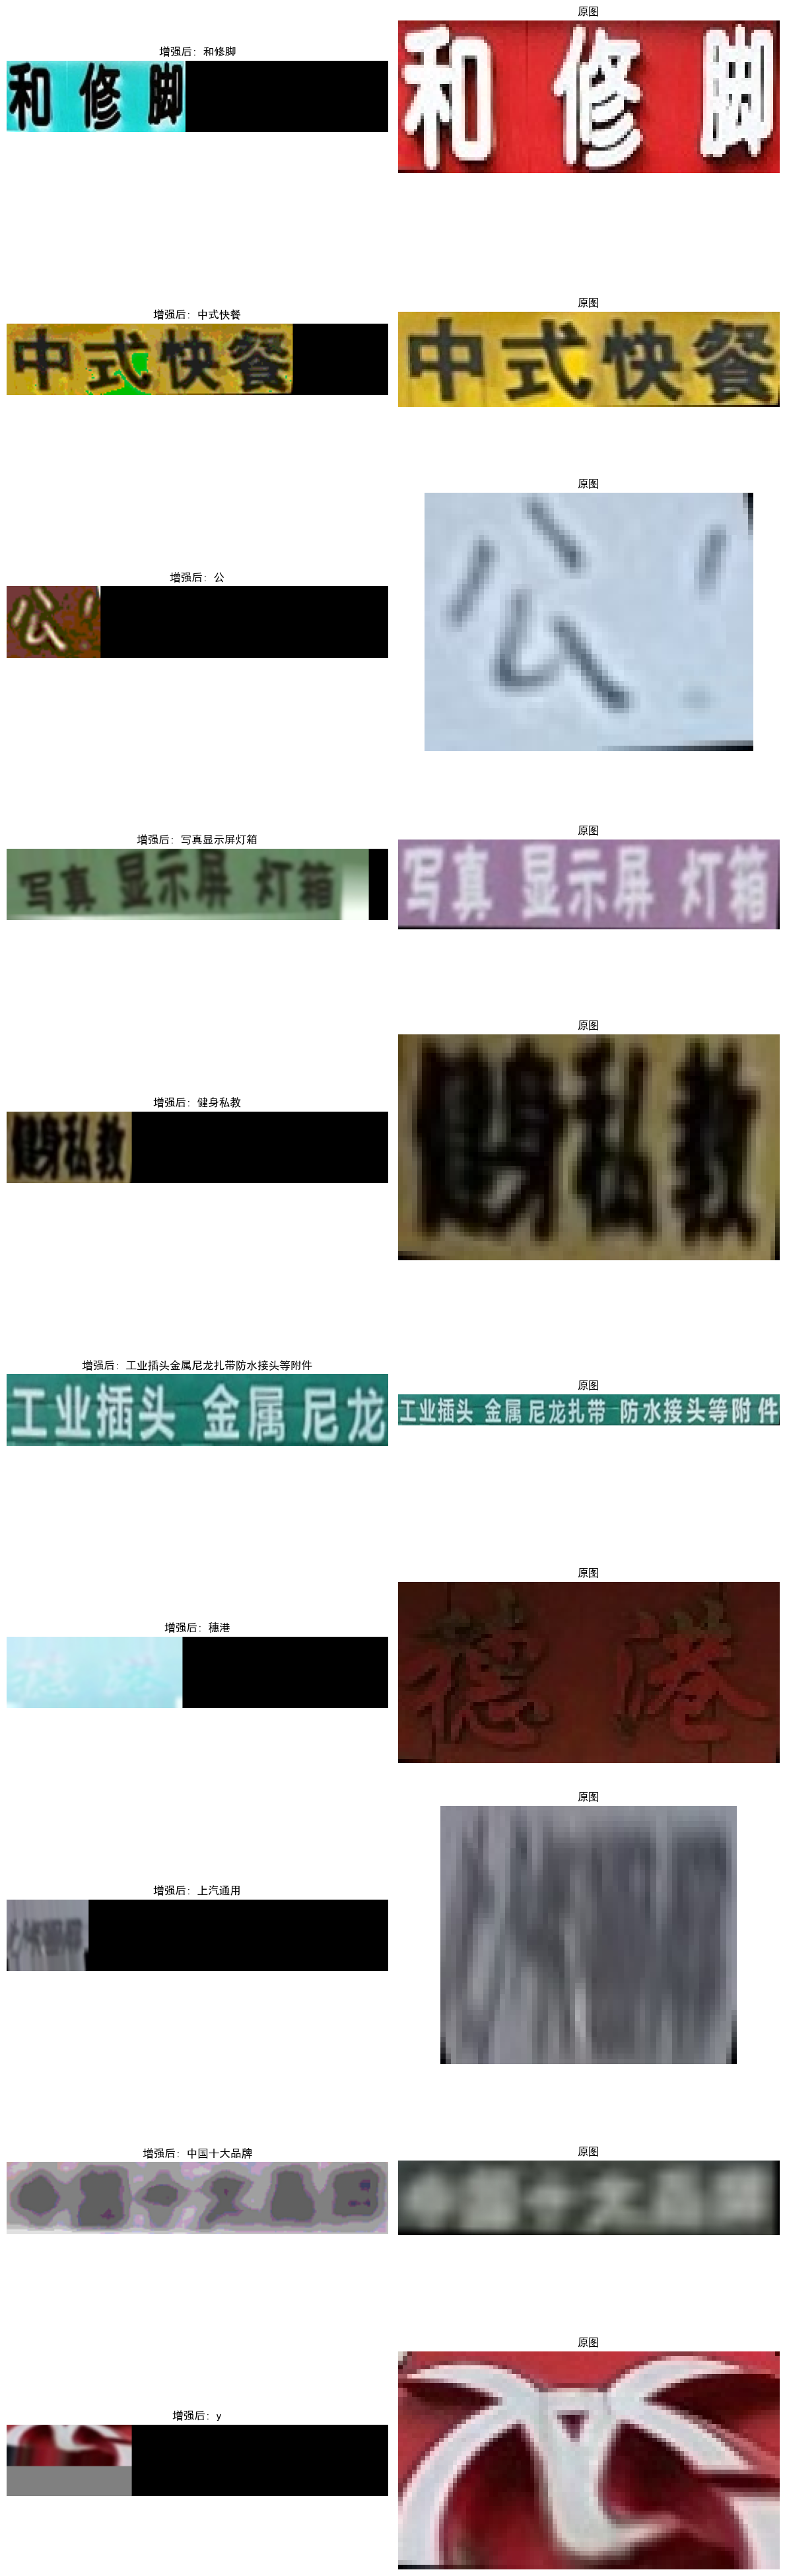

In [70]:
import matplotlib.pyplot as plt
import numpy as np
import cv2
import os

idx2char = {v: k for k, v in train_dataset.char2idx.items()}

selected_indices = np.random.choice(len(train_dataset), 10, replace=False)

fig, axes = plt.subplots(10, 2, figsize=(12, 40))

for row, sample_idx in enumerate(selected_indices):
    img_tensor, padded_label, _ = train_dataset[sample_idx]
    img_np = img_tensor.numpy().transpose(1, 2, 0)
    img_np = (img_np * 0.5 + 0.5) * 255.0
    img_np = np.clip(img_np, 0, 255).astype(np.uint8)
    img_rgb = cv2.cvtColor(img_np, cv2.COLOR_BGR2RGB)

    label_text = "".join([idx2char[int(idx)] for idx in padded_label if int(idx) != train_dataset.blank_idx])

    axes[row, 0].imshow(img_rgb)
    axes[row, 0].set_title(f"增强后: {label_text}")
    axes[row, 0].axis('off')

    real_idx = train_dataset.indices[sample_idx]
    img_name, _ = train_dataset.data_list[real_idx]
    orig = cv2.imread(os.path.join(train_dataset.image_dir, img_name))
    orig_rgb = cv2.cvtColor(orig, cv2.COLOR_BGR2RGB)
    axes[row, 1].imshow(orig_rgb)
    axes[row, 1].set_title("原图")
    axes[row, 1].axis('off')

plt.tight_layout()
plt.show()


## 下载模型
在 [文本识别算法](https://github.com/PaddlePaddle/PaddleOCR/blob/develop/doc/doc_ch/algorithm_overview.md#2%E6%96%87%E6%9C%AC%E8%AF%86%E5%88%AB%E7%AE%97%E6%B3%95)
 中能找到很多预训练模型，这些模型使用MJSynth和SynthText两个文字识别数据集训练。针对本次常规赛，可以使用训练集对模型进行微调。以CRNN模型为例，下面的代码可以将预训练模型下载到AI Studio：

In [71]:
# ! wget -P model https://paddleocr.bj.bcebos.com/rec_r34_vd_none_bilstm_ctc.tar && \
#   cd model && \
#   tar xf rec_r34_vd_none_bilstm_ctc.tar && \
#   rm rec_r34_vd_none_bilstm_ctc.tar

## ......
下载完预训练模型后，可通过 -c 参数选择 PaddleOCR/configs/rec/ 路径下的多种模型配置进行训练。为了让大家熟悉PaddleOCR的使用，训练配置就留给大家自己选择，不在再多做介绍。在完成训练配置后，就可以开始训练了！

[PaddleOCR主页](https://github.com/PaddlePaddle/PaddleOCR) 如果repo对你能够帮助，可以点一个star支持一下呀~~

大家在提交结果文件的时候需要注意，我们的 `*.txt` 文件需要以下格式（**注意第一行**）：

| new_name | value | 
| :-: | :-: | 
| 0.jpg | 识别结果0 | 
| 1.jpg | 识别结果1 |
| 2.jpg | 识别结果2 |
|  ...  |  ...    |
| 9999.jpg | 识别结果9999 |

预祝各位选手取得好成绩![](https://ai-studio-static-online.cdn.bcebos.com/61ee3d38b0964fa49925143ce5109b333b16d02120274965a47f87d76991e2a6)
